# Smart MCQ Solver Challenge

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


## Quickstart: Tracking your first run in Weights & Biases

In [3]:
# pip install wandb

In [4]:
# import wandb
# wandb.login()

In [5]:
# ## Logs a run to new project

# import random

# import wandb

# # Start a new wandb run to track this script.
# run = wandb.init(
#     # Set the wandb entity where your project will be logged (generally your team name).
#     entity="23f3001252-dl-genai-project",
#     # Set the wandb project where this run will be logged.
#     project="23f3001252-t22026",
#     # Track hyperparameters and run metadata.
#     config={
#         "learning_rate": 0.02,
#         "architecture": "CNN",
#         "dataset": "CIFAR-100",
#         "epochs": 10,
#     },
# )

# # Simulate training.
# epochs = 10
# offset = random.random() / 5
# for epoch in range(2, epochs):
#     acc = 1 - 2**-epoch - random.random() / epoch - offset
#     loss = 2**-epoch + random.random() / epoch + offset

#     # Log metrics to wandb.
#     run.log({"acc": acc, "loss": loss})

# # Finish the run and upload any remaining data.
# run.finish()

## Load the datasets

In [6]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

In [7]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Sample Shape:", sample.shape)

Train Shape: (2000, 8)
Test Shape: (500, 7)
Sample Shape: (500, 2)


In [8]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

## EDA

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [10]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [11]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


### Check missing values

In [12]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [13]:
test.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64

### Check class distributions

In [14]:
train["answer"].value_counts(normalize=True) * 100

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

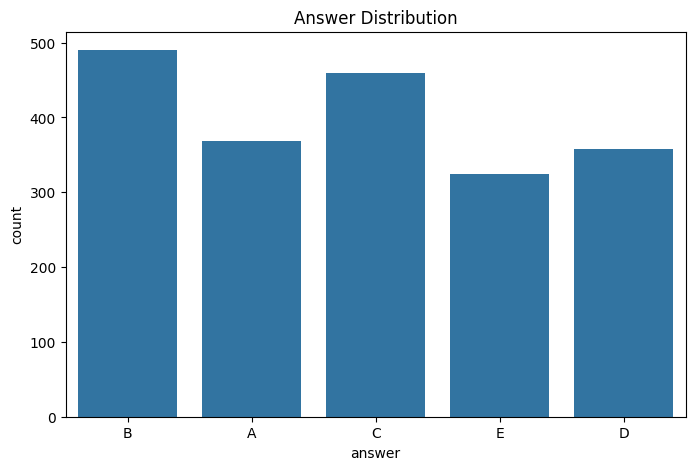

In [15]:
### Visualize class distributions

plt.figure(figsize=(8,5))

sns.countplot(
    data=train,
    x="answer"
)

plt.title("Answer Distribution")
plt.show()

In [16]:
df1 = train.copy()
df2 = test.copy()

### Prompt Length Analysis

Long questions usually favor transformers.

In [17]:
df1["prompt_length"] = (
    train["prompt"]
    .astype(str)
    .str.len()
)

In [18]:
df1["prompt_length"].describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_length, dtype: float64

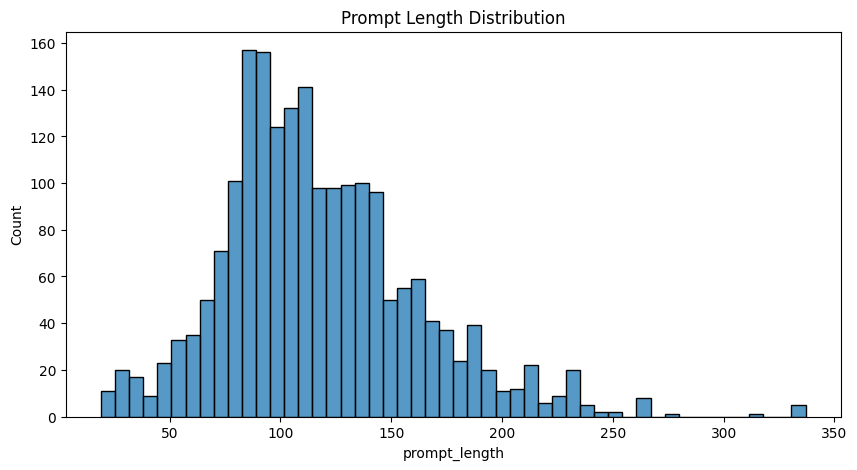

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df1["prompt_length"],
    bins=50
)

plt.title("Prompt Length Distribution")
plt.show()


### Option-wise Length Analysis

In [20]:
for col in ['A','B','C','D','E']:
    df1[f'{col}_length'] = (
        train[col]
        .astype(str)
        .str.len()
    )

In [21]:
### Average Length
for col in ['A','B','C','D','E']:
    print(
        col,
        df1[f'{col}_length'].mean()
    )

A 164.0915
B 166.6165
C 167.227
D 162.5635
E 164.23


### Check duplicated values in prompt cols

In [22]:
df1["prompt"].duplicated().sum()

np.int64(242)

In [23]:
df1.head()

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,142,307,258,222,202,191
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,43,406,364,365,407,408
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,182,12,11,9,9,9
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,129,307,258,222,202,191
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,110,230,233,233,99,99


## Make EDA Summary

In [24]:
eda_summary = {
    "train_shape": train.shape,
    "test_shape": test.shape,
    "missing_values": train.isnull().sum().to_dict(),
    "answer_distribution": train["answer"].value_counts().to_dict(),
    "avg_prompt_length": df1["prompt_length"].mean(),
    "duplicated values in prompt column": df1["prompt"].duplicated().sum(),
    "options_distribution": {
        col: df1[f"{col}_length"].mean()
        for col in ["A", "B", "C", "D", "E"]
    }
}

In [25]:
eda_summary

{'train_shape': (2000, 8),
 'test_shape': (500, 7),
 'missing_values': {'id': 0,
  'prompt': 0,
  'A': 0,
  'B': 0,
  'C': 0,
  'D': 0,
  'E': 0,
  'answer': 0},
 'answer_distribution': {'B': 490, 'C': 459, 'A': 369, 'D': 358, 'E': 324},
 'avg_prompt_length': np.float64(117.6695),
 'duplicated values in prompt column': np.int64(242),
 'options_distribution': {'A': np.float64(164.0915),
  'B': np.float64(166.6165),
  'C': np.float64(167.227),
  'D': np.float64(162.5635),
  'E': np.float64(164.23)}}

## Completion Metric (MAP@3)

In [26]:
## AP@3
def apk(actual, predicted, k=3):
    """
    actual: true label (A/B/C/D/E)
    predicted: list of predictions
    """

    predicted = predicted[:k]

    if actual in predicted:
        return 1.0 / (predicted.index(actual) + 1)

    return 0.0

In [ ]:
## MAP@3
def mapk(actuals, predictions):
    scores = []

    for actual, pred in zip(actuals, predictions):
        scores.append(apk(actual, pred))

    return np.mean(scores)

In [29]:
## test map@3
actuals = ['A', 'C', 'B']

preds = [
    ['A','B','C'],
    ['A','C','D'],
    ['D','A','B']
]

print(mapk(actuals, preds))

0.611111111111111


## Baseline pipeline

In [40]:
def create_text(row):
    return f"""
Question: {row['prompt']}
Option A: {row['A']}
Option B: {row['B']}
Option C: {row['C']}
Option D: {row['D']}
Option E: {row['E']}
"""

In [41]:
df1["text"] = df1.apply(create_text, axis=1)

In [43]:

df1["text_length"] = df1["text"].str.len()

In [ ]:
## Encode labels
label_map = {
    'A':0,
    'B':1,
    'C':2,
    'D':3,
    'E':4
}

df1["label"] = df1["answer"].map(label_map)

In [42]:
## Reverse mapping
id2label = {v:k for k, v in label_map.items()}

In [45]:
df1.text[0]

"\nQuestion: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.\nOption A: Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.\nOption B: Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.\nOption C: Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.\nOption D: Martin Hei

In [47]:
df1.head()

,id,prompt,A,B,C,D,E,answer,prompt_length,A_length,B_length,C_length,D_length,E_length,text,label,text_length
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,142,307,258,222,202,191,\nQuestion: Pick the best possible answer: Wha...,1,1389
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A,43,406,364,365,407,408,\nQuestion: What is accelerator-based light-io...,0,2060
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C,182,12,11,9,9,9,\nQuestion: Determine the correct option: What...,2,299
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B,129,307,258,222,202,191,\nQuestion: Select the most accurate option: W...,1,1376
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A,110,230,233,233,99,99,\nQuestion: Identify the correct statement: Wh...,0,1071


In [27]:
# sample.to_csv("submission.csv", index=False)